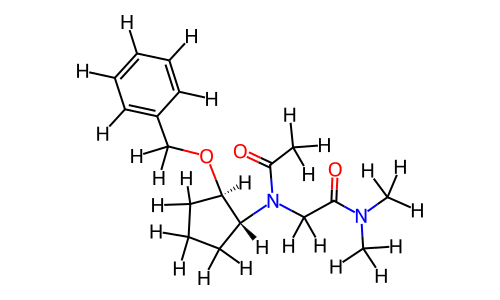

In [8]:
from openff.toolkit import Molecule

mol = Molecule.from_file("s06.sdf")

# visualize
mol.visualize()

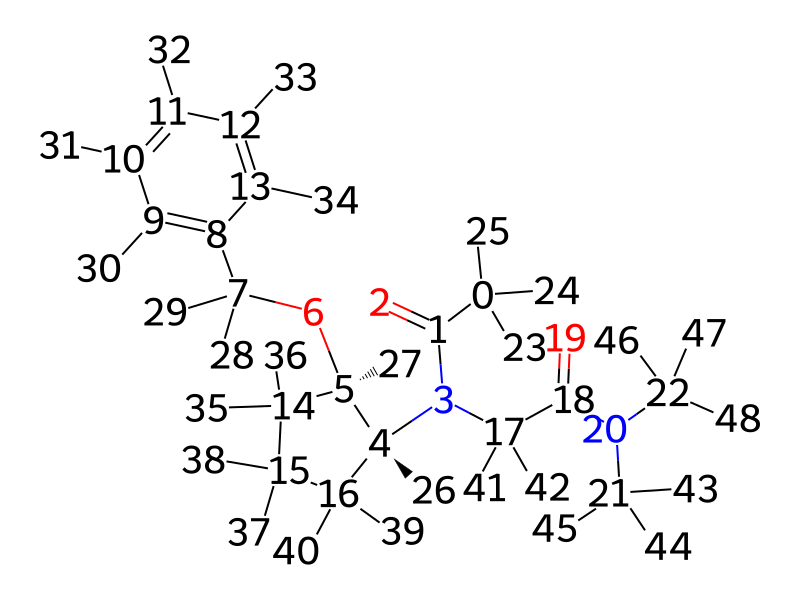

In [9]:
from rdkit import Chem
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import Image, display

rdmol = Chem.MolFromMolFile("s06.sdf", removeHs=False)

for atom in rdmol.GetAtoms():
    atom.SetProp("atomLabel", str(atom.GetIdx()))

rdDepictor.Compute2DCoords(rdmol)

drawer = rdMolDraw2D.MolDraw2DCairo(800, 600)
drawer.DrawMolecule(rdmol)
drawer.FinishDrawing()

with open("s06.png", "wb") as f:
    f.write(drawer.GetDrawingText())

display(Image(filename="s06.png"))

In [10]:
from openff.toolkit import Molecule
from rdkit.Chem import rdMolTransforms

mol = Molecule.from_file("s06.sdf")
mol.generate_conformers(n_conformers=50)

# atom index
a, b, c, d = 1, 3, 17, 18

rdmol = mol.to_rdkit()
angles = []

for i, conf in enumerate(rdmol.GetConformers()):
    angle = rdMolTransforms.GetDihedralDeg(conf, a, b, c, d)
    angles.append(angle)
    print(f"Conformer {i:2d}: {angle:8.2f}°")

Conformer  0:   -88.15°
Conformer  1:    89.02°
Conformer  2:   -89.94°
Conformer  3:   -89.73°
Conformer  4:    89.28°
Conformer  5:   -89.89°
Conformer  6:   -86.68°
Conformer  7:    89.89°
Conformer  8:    86.83°
Conformer  9:   -86.61°
Conformer 10:   -85.42°
Conformer 11:   -90.00°
Conformer 12:   -86.00°
Conformer 13:    89.28°
Conformer 14:   -84.02°
Conformer 15:   -86.73°
Conformer 16:   -89.95°


[np.float64(-88.14988382951913), np.float64(89.0241638211181), np.float64(-89.93651717849393), np.float64(-89.73289239919102), np.float64(89.27837982712731), np.float64(-89.89278493740709), np.float64(-86.67728223584577), np.float64(89.88545134605211), np.float64(86.82727393333444), np.float64(-86.6126538757799), np.float64(-85.41678385746117), np.float64(-89.9992327529092), np.float64(-85.9996855084283), np.float64(89.27649229873184), np.float64(-84.01506438584471), np.float64(-86.73433633646343), np.float64(-89.95223414069956), np.float64(88.75035925185281), np.float64(-86.1425317382018), np.float64(-83.18971856918041), np.float64(89.42558322702794), np.float64(-89.81201929240804), np.float64(87.52207906859095), np.float64(89.46372164517928), np.float64(86.58138665293731), np.float64(86.89304992997451), np.float64(-85.26597887471623), np.float64(88.4999108670143), np.float64(-83.84458877394069), np.float64(88.12216024215213), np.float64(87.42680876543537), np.float64(-89.995736795098

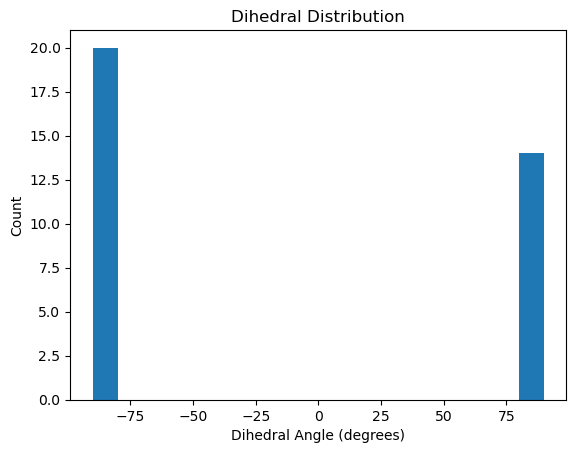

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from openff.toolkit import Molecule

def dihedral_angle(p0, p1, p2, p3):
    """Return dihedral angle in degrees."""
    b0 = -1.0 * (p1 - p0)
    b1 = p2 - p1
    b2 = p3 - p2

    # normalize b1 so projection is stable
    b1 /= np.linalg.norm(b1)

    # vectors perpendicular to b1
    v = b0 - np.dot(b0, b1) * b1
    w = b2 - np.dot(b2, b1) * b1

    x = np.dot(v, w)
    y = np.dot(np.cross(b1, v), w)

    angle = np.degrees(np.arctan2(y, x))
    return angle

mol = Molecule.from_file("s06.sdf")
mol.generate_conformers(n_conformers=200)

# phi atom index
dihedral_atoms = [1, 3, 17, 18]

angles = []

for conf in mol.conformers:
    coords = conf.m_as("angstrom")   # shape: (n_atoms, 3)
    i, j, k, l = dihedral_atoms
    angle = dihedral_angle(coords[i], coords[j], coords[k], coords[l])
    angles.append(angle)

print(angles)

plt.hist(angles, bins=18)
plt.xlabel("Dihedral Angle (degrees)")
plt.ylabel("Count")
plt.title("Dihedral Distribution")
plt.show()

In [12]:
import numpy as np

angles_array = np.array(angles)

counts, bins = np.histogram(angles_array, bins=18)

# find 
top2 = np.argsort(counts)[-2:]

peak_angles = [(bins[i] + bins[i+1]) / 2 for i in top2]

print("Top dihedral angles:")
for p in peak_angles:
    print(f"≈ {p:.2f}°")

Top dihedral angles:
≈ 84.89°
≈ -85.00°


[np.float64(-179.5336753677692), np.float64(179.69625303107892), np.float64(-179.98608561676164), np.float64(-179.98493370592942), np.float64(-179.29461129866004), np.float64(-0.15944332078465462), np.float64(-178.80908881070187), np.float64(179.96586447094643), np.float64(-2.486153783454682), np.float64(-179.2492781554123), np.float64(-179.19480852979794), np.float64(-179.99976901205756), np.float64(-178.61075328539673), np.float64(179.75473976729458), np.float64(5.145601171069754), np.float64(-178.81034182286845), np.float64(-179.99943409508407), np.float64(-0.5472482382144578), np.float64(-178.69843625249362), np.float64(4.964679674060573), np.float64(-179.9984506237744), np.float64(-0.3017896915585059), np.float64(179.14971977048535), np.float64(179.83957010269907), np.float64(179.0034650085939), np.float64(-1.96025334878176), np.float64(3.0809151666218213), np.float64(179.52861195739814), np.float64(5.392304368961659), np.float64(-1.6870683302463487), np.float64(-1.782532571734924

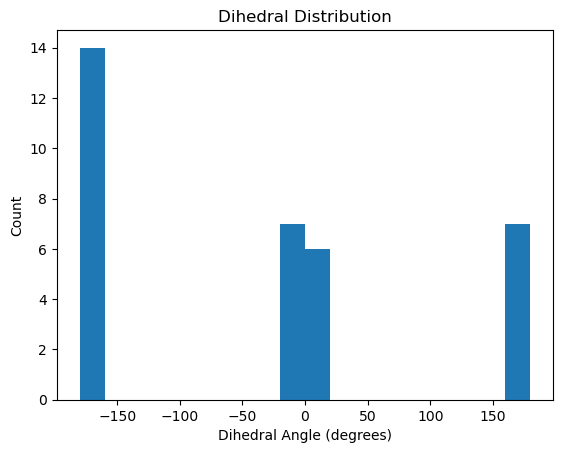

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from openff.toolkit import Molecule

def dihedral_angle(p0, p1, p2, p3):
    """Return dihedral angle in degrees."""
    b0 = -1.0 * (p1 - p0)
    b1 = p2 - p1
    b2 = p3 - p2

    # normalize b1 so projection is stable
    b1 /= np.linalg.norm(b1)

    # vectors perpendicular to b1
    v = b0 - np.dot(b0, b1) * b1
    w = b2 - np.dot(b2, b1) * b1

    x = np.dot(v, w)
    y = np.dot(np.cross(b1, v), w)

    angle = np.degrees(np.arctan2(y, x))
    return angle

mol = Molecule.from_file("s06.sdf")
mol.generate_conformers(n_conformers=200)

# psi atom index
dihedral_atoms = [3, 17, 18, 20]

angles = []

for conf in mol.conformers:
    coords = conf.m_as("angstrom")   # shape: (n_atoms, 3)
    i, j, k, l = dihedral_atoms
    angle = dihedral_angle(coords[i], coords[j], coords[k], coords[l])
    angles.append(angle)

print(angles)

plt.hist(angles, bins=18)
plt.xlabel("Dihedral Angle (degrees)")
plt.ylabel("Count")
plt.title("Dihedral Distribution")
plt.show()

In [14]:
import numpy as np

angles_array = np.array(angles)

counts, bins = np.histogram(angles_array, bins=18)

# find 
top2 = np.argsort(counts)[-2:]

peak_angles = [(bins[i] + bins[i+1]) / 2 for i in top2]

print("Top dihedral angles:")
for p in peak_angles:
    print(f"≈ {p:.2f}°")

Top dihedral angles:
≈ 169.97°
≈ -170.00°


In [15]:
import sys
print(sys.executable)

/home/tuu61186/miniconda3/envs/openff/bin/python


In [16]:
import setuptools
print(setuptools.__version__)

82.0.1


In [17]:
import sys
!{sys.executable} -m pip install setuptools

In [18]:
import pkg_resources
print("pkg_resources OK")

from openff.toolkit.typing.engines.smirnoff import ForceField
ff = ForceField("openff-2.2.0.offxml")
print("ForceField OK")

pkg_resources OK


ForceField OK


In [19]:
from openff.toolkit import Molecule
from openff.toolkit.typing.engines.smirnoff import ForceField
from openmm import Context, VerletIntegrator
from openmm import unit as omm_unit

mol = Molecule.from_file("s06.sdf")
mol.generate_conformers(n_conformers=50)

ff = ForceField("openff-2.2.0.offxml")
system = ff.create_openmm_system(mol.to_topology())

integrator = VerletIntegrator(1.0 * omm_unit.femtoseconds)
context = Context(system, integrator)

energies = []
for conf in mol.conformers:
    positions = conf.to_openmm()
    context.setPositions(positions)
    state = context.getState(getEnergy=True)
    energy = state.getPotentialEnergy().value_in_unit(omm_unit.kilojoule_per_mole)
    energies.append(energy)

print(energies[:5])

[261.43936768328257, 288.16659628554555, 296.9775070931828, 291.66607680741015, 340.2423891947694]


In [20]:
import numpy as np

energies = np.array(energies)
rel_energies = energies - energies.min()

print("Absolute energies:", energies)
print("Relative energies:", rel_energies)

Absolute energies: [261.43936768 288.16659629 296.97750709 291.66607681 340.24238919
 358.85787324 323.89698412 299.76336529 417.08024372 315.63283835
 426.35596061 290.91107735 303.82107101 257.30279865 402.46864585
 339.34779797 276.40592587]
Relative energies: [  4.13656904  30.86379764  39.67470845  34.36327816  82.93959055
 101.55507459  66.59418548  42.46056664 159.77744508  58.3300397
 169.05316196  33.60827871  46.51827237   0.         145.16584721
  82.04499933  19.10312722]


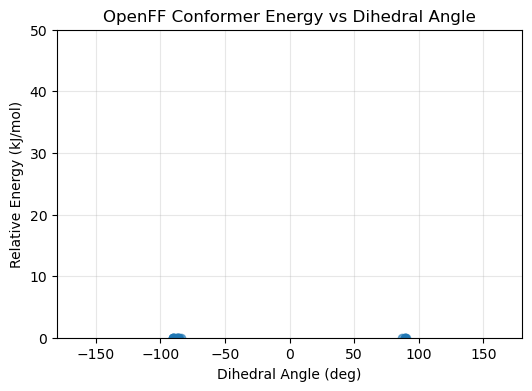

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from openff.toolkit import Molecule

def dihedral_angle(p0, p1, p2, p3):
	"""Return dihedral angle in degrees."""
	b0 = -1.0 * (p1 - p0)
	b1 = p2 - p1
	b2 = p3 - p2

	b1 /= np.linalg.norm(b1)

	v = b0 - np.dot(b0, b1) * b1
	w = b2 - np.dot(b2, b1) * b1

	x = np.dot(v, w)
	y = np.dot(np.cross(b1, v), w)

	return np.degrees(np.arctan2(y, x))

if "angles" not in globals():
	if "mol" not in globals():
		mol = Molecule.from_file("s06.sdf")
		mol.generate_conformers(n_conformers=50)

	dihedral_atoms = [1, 3, 17, 18]
	angles = []
	for conf in mol.conformers:
		coords = conf.m_as("angstrom")
		i, j, k, l = dihedral_atoms
		angles.append(dihedral_angle(coords[i], coords[j], coords[k], coords[l]))

if "rel_energies" not in globals():
	if "energies" in globals():
		energies_array = np.array(energies)
		rel_energies = energies_array - energies_array.min()
	else:
		rel_energies = np.zeros_like(angles)
		print("Warning: 'energies' is not defined; plotting with zero relative energies.")

plt.figure(figsize=(6,4))

plt.scatter(angles, rel_energies, alpha=0.6)

plt.xlabel("Dihedral Angle (deg)")
plt.ylabel("Relative Energy (kJ/mol)")
plt.title("OpenFF Conformer Energy vs Dihedral Angle")

plt.xlim(-180, 180)
plt.ylim(0, 50)  # adjust as needed

plt.grid(alpha=0.3)
plt.show()